In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib as mpl
mpl.style.use('classic')
import matplotlib.pyplot as plt
%matplotlib inline

### 1. Read and explore the dataset. (Rename column, plot histograms, find data characteristics

In [2]:
df = pd.read_csv('ratings_Electronics.csv', header=None)
df.columns = ['userid', 'productid', 'rating', 'timestamp']
df.sample(3)

,userid,productid,rating,timestamp
1441524,ACK9Q4NLXTKS8,B000VIHFZ4,5.0,1265587200
5661446,A1I5IMCFDCP2F2,B0077SL8GS,2.0,1386374400
490862,A1TH2RT1M2WWRE,B0002L5R78,5.0,1393632000


In [3]:
df.drop('timestamp', axis=1, inplace=True)

In [4]:
df.shape

(7824482, 3)

In [5]:
df.isna().any()

userid       False
productid    False
rating       False
dtype: bool

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7824482 entries, 0 to 7824481
Data columns (total 3 columns):
userid       object
productid    object
rating       float64
dtypes: float64(1), object(2)
memory usage: 179.1+ MB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rating,7824482.0,4.012337,1.38091,1.0,3.0,5.0,5.0,5.0


In [8]:
user_uniq = len(df['userid'].unique())
prod_uniq = len(df['productid'].unique())
print(f'unique user -> {user_uniq}')
print(f'unique products -> {prod_uniq}')

unique user -> 4201696
unique products -> 476002


In [9]:
df['rating'].median()

5.0

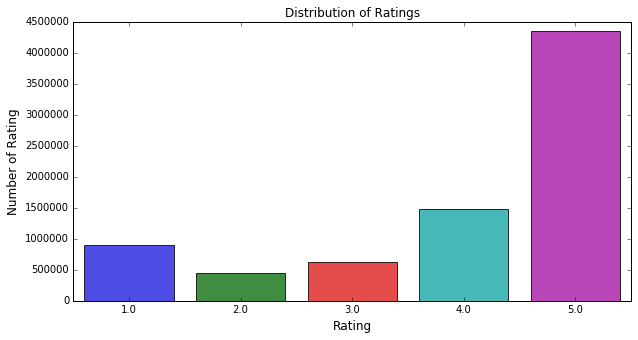

In [10]:
rating_cnt  = df['rating'].value_counts()
plt.figure(figsize=(10,5))
sns.barplot(rating_cnt.index, rating_cnt.values, alpha=0.8)
plt.title('Distribution of Ratings')
plt.ylabel('Number of Rating', fontsize=12)
plt.xlabel('Rating', fontsize=12)
plt.show()

### 2. Take subset of dataset to make it less sparse/more dense. (For example, keep the users only who has given 50 or more number of ratings )

In [11]:
usr_cnt = df.userid.value_counts()
usr_cnt = usr_cnt[usr_cnt > 50]
users = usr_cnt.index.tolist()

In [12]:
df['test'] = np.where(df.userid.isin(users), 1, 0)
df_dropped = df[df['test'] == 1]
df.drop('test', axis=1, inplace=True)
df_dropped.drop('test', axis=1, inplace=True)
df_dropped.sample(2)

/home/swaraj/apps/anaconda/lib/python3.6/site-packages/pandas/core/frame.py:3930: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  errors=errors)


,userid,productid,rating
3871633,A8CKH8XB33XGN,B0044XTJ10,5.0
2796506,AGFSSC5DBY2HU,B002R5AM7C,4.0


###  3. Split the data randomly into train and test dataset. (For example split it in 70/30 ratio)

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
train_data, test_data = train_test_split(df_dropped, test_size = 0.30, random_state=0)
train_data.sample(3)

,userid,productid,rating
7552686,A680RUE1FDO8B,B00EOAS4KU,5.0
2469109,A27AF4DLLOBQDQ,B0027VT6OG,4.0
304856,A1XXMNLOLKNO0I,B00009XV1J,5.0


### 4. Build Popularity Recommender model.

In [28]:
#Top 20 highly rated products, Popularity Model by avg rating We will use formula sa (num_user_rated*avg_rating/tot_unique_user *100)
uniq_user = len(train_data['userid'].unique())
train_df = train_data.groupby('productid', as_index=False).agg({'userid':'count','rating':'mean'}).rename(columns={'userid':'num_user_rated','rating':'avg_rating'})
train_df['rating_perc'] = ((train_df['num_user_rated'] * train_df['avg_rating'])/uniq_user)*100
top_10_train = train_df.sort_values(by='rating_perc', ascending=False)[:10]['productid'].tolist()
top_10_train

['B0088CJT4U',
 'B003ES5ZUU',
 'B000N99BBC',
 'B007WTAJTO',
 'B00829TIEK',
 'B00829THK0',
 'B004CLYEDC',
 'B002R5AM7C',
 'B0034CL2ZI',
 'B004CLYEFK']

In [29]:
#Running Same on Test Data
uniq_user = len(test_data['userid'].unique())
test_df = test_data.groupby('productid', as_index=False).agg({'userid':'count','rating':'mean'}).rename(columns={'userid':'num_user_rated','rating':'avg_rating'})
test_df['rating_perc'] = ((test_df['num_user_rated'] * test_df['avg_rating'])/uniq_user)*100
top_10_test = test_df.sort_values(by='rating_perc', ascending=False)[:10]['productid'].tolist()
top_10_test

['B000N99BBC',
 'B007WTAJTO',
 'B003ES5ZUU',
 'B0088CJT4U',
 'B008DWCRQW',
 'B00829TIEK',
 'B002R5AM7C',
 'B00829THK0',
 'B002V88HFE',
 'B004CLYEDC']

In [34]:
#Match in Test and train result
match = [value for value in top_10_train if value in top_10_test] 
print(f'Score = {len(match)*10}')

Score = 80


### 5. Build Collaborative Filtering model.

In [35]:
#Collborative Filtering
from surprise import Dataset,Reader
reader = Reader(rating_scale=(1, 5))

In [36]:
data = Dataset.load_from_df(df_dropped[['userid', 'productid', 'rating']], reader)

In [37]:
from surprise.model_selection import train_test_split
trainset, testset = train_test_split(data, test_size=.30,random_state=0)

In [43]:
from surprise import SVD
from surprise import accuracy

In [44]:
svd_model = SVD(n_factors=50,biased=False)
svd_model.fit(trainset)

### 6. Evaluate both the models. (Once the model is trained on the training data, it can be used to compute the error (RMSE) on predictions made on the test data.)

In [45]:
test_pred = svd_model.test(testset)
accuracy.rmse(test_pred)

RMSE: 2.0502


2.0501894914747245

### 7. Get top - K (K = 5) recommendations. Since our goal is to recommend new products to each user based on his/her habits,we will recommend 5 new products.

In [46]:
testset_new = trainset.build_anti_testset()
#for K=5
testset_new[0:5]

[('A18A5VSD0IPN14', 'B003RRFWRY', 4.262666775804207),
 ('A18A5VSD0IPN14', 'B002HWRJXU', 4.262666775804207),
 ('A18A5VSD0IPN14', 'B004Z24L2W', 4.262666775804207),
 ('A18A5VSD0IPN14', 'B001TOD7ME', 4.262666775804207),
 ('A18A5VSD0IPN14', 'B002KC55OM', 4.262666775804207)]

### 8. Summarise your insights.

In [ ]:
# As we  can see popularity based is always same for each user all product range as it only depends on average score where as the other one is rightnow done using product content we can make it more specific user based recommendation which can be very useful in real life scenario and it can change based on user behaviour